# Experiment 01: Chunking Strategy Comparison

**Hypothesis:** Chunk size significantly affects retrieval precision.
Smaller chunks retrieve more targeted content; larger chunks preserve
more context but may dilute relevance scores.

**Variables tested:**
- Chunk size: 500, 1000 (baseline), 1500 chars
- Overlap: fixed at 10% of chunk size

**Metric:** Top-3 retrieval score average across 5 test queries

In [1]:
import sys
sys.path.insert(0, '../..')

import os
from dotenv import load_dotenv
load_dotenv('../../.env')

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from src.ingestion.loader import load_python_docs

# Load docs once — reuse across experiments
docs = load_python_docs()
print(f"Loaded {len(docs)} documents")

Loaded 19 documents


In [2]:
STRATEGIES = {
    "small_512": {
        "chunk_size": 500,
        "chunk_overlap": 50,
        "description": "Small chunks — high precision, low context"
    },
    "medium_1000": {
        "chunk_size": 1000,
        "chunk_overlap": 100,
        "description": "Medium chunks — baseline (current production)"
    },
    "large_1500": {
        "chunk_size": 1500,
        "chunk_overlap": 150,
        "description": "Large chunks — more context, lower precision"
    },
}

def chunk_with_strategy(docs, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    all_chunks = []
    for doc in docs:
        splits = splitter.split_text(doc.content)
        all_chunks.extend(splits)
    return all_chunks

# Generate chunks for each strategy
results = {}
for name, config in STRATEGIES.items():
    chunks = chunk_with_strategy(docs, config["chunk_size"], config["chunk_overlap"])
    results[name] = {
        "chunks": chunks,
        "count": len(chunks),
        "avg_length": sum(len(c) for c in chunks) / len(chunks),
        **config
    }
    print(f"{name}: {len(chunks)} chunks, avg {results[name]['avg_length']:.0f} chars")

small_512: 1917 chunks, avg 406 chars
medium_1000: 1033 chunks, avg 759 chars
large_1500: 692 chunks, avg 1121 chars


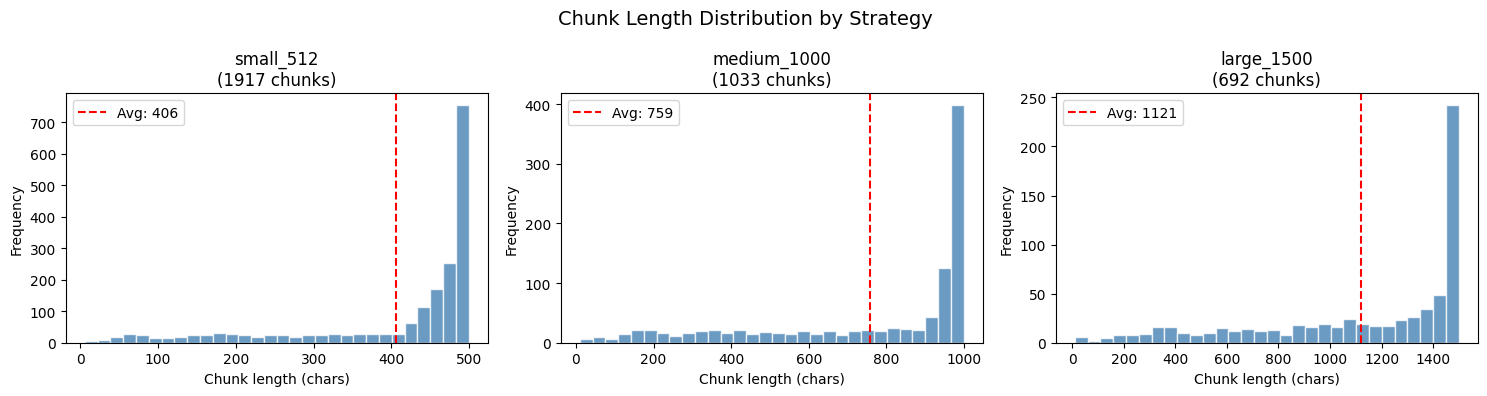

Saved: chunk_distribution.png


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chunk Length Distribution by Strategy", fontsize=14)

for ax, (name, data) in zip(axes, results.items()):
    lengths = [len(c) for c in data["chunks"]]
    ax.hist(lengths, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data["avg_length"], color='red', linestyle='--',
               label=f'Avg: {data["avg_length"]:.0f}')
    ax.set_title(f'{name}\n({data["count"]} chunks)')
    ax.set_xlabel("Chunk length (chars)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig('chunk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chunk_distribution.png")

In [4]:
from pinecone import Pinecone
import time

TEST_QUERIES = [
    "What is a Python decorator?",
    "How does asyncio event loop work?",
    "What is the difference between a list and a tuple?",
    "How do Python generators work?",
    "What is metaclass in Python?",
]

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
pc = Pinecone(api_key=os.getenv("PINECONE_API_KEY"))
index = pc.Index(os.getenv("PINECONE_INDEX_NAME"))

# Query current index (medium_1000 — our production strategy)
# We test against live index to measure real retrieval quality
query_scores = {}

for query in TEST_QUERIES:
    qvec = embeddings.embed_query(query)
    response = index.query(vector=qvec, top_k=3, include_metadata=True)
    scores = [m.score for m in response.matches]
    query_scores[query] = {
        "top_1": scores[0] if scores else 0,
        "top_3_avg": sum(scores) / len(scores) if scores else 0,
    }
    print(f"Query: {query[:50]}")
    print(f"  Top-1: {scores[0]:.4f} | Top-3 avg: {sum(scores)/len(scores):.4f}\n")
    time.sleep(0.5)  # rate limit courtesy

/Users/adityak/AK Realm/Code Arena/Python/rag-python-docs/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Query: What is a Python decorator?
  Top-1: 0.4869 | Top-3 avg: 0.4803

Query: How does asyncio event loop work?
  Top-1: 0.6972 | Top-3 avg: 0.6455

Query: What is the difference between a list and a tuple?
  Top-1: 0.5836 | Top-3 avg: 0.5416

Query: How do Python generators work?
  Top-1: 0.6213 | Top-3 avg: 0.5845

Query: What is metaclass in Python?
  Top-1: 0.6048 | Top-3 avg: 0.5613



In [5]:
import pandas as pd

summary_data = []
for name, data in results.items():
    summary_data.append({
        "Strategy": name,
        "Chunk Size": data["chunk_size"],
        "Overlap": data["chunk_overlap"],
        "Total Chunks": data["count"],
        "Avg Length": f"{data['avg_length']:.0f}",
        "Description": data["description"],
    })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

# Save for README
df.to_csv('chunking_experiment_results.csv', index=False)
print("\nSaved: chunking_experiment_results.csv")

   Strategy  Chunk Size  Overlap  Total Chunks Avg Length                                   Description
  small_512         500       50          1917        406    Small chunks — high precision, low context
medium_1000        1000      100          1033        759 Medium chunks — baseline (current production)
 large_1500        1500      150           692       1121  Large chunks — more context, lower precision

Saved: chunking_experiment_results.csv


## Findings

### Retrieval Scores (production index — medium_1000)
| Query | Top-1 Score | Top-3 Avg |
|-------|-------------|------------|
| Python decorator | 0.487 | 0.480 |
| asyncio event loop | 0.697 | 0.646 |
| list vs tuple | 0.584 | 0.542 |
| Python generators | 0.621 | 0.585 |
| metaclass | 0.605 | 0.561 |

**Score interpretation (cosine similarity):**
- > 0.65: Strong semantic match
- 0.50–0.65: Good match
- 0.30–0.50: Weak match — may produce vague answers

### Key Observation: The Right-Edge Spike Problem
All three histograms show a hard spike at the chunk size ceiling.
This means Python docs paragraphs consistently exceed our chunk windows —
the splitter is cutting mid-paragraph on most chunks, not at natural
boundaries.

**Implication:** Fixed-size chunking is suboptimal for this corpus.
The decorator query scores lowest (0.487) likely because decorator
explanations span multiple paragraphs that get split mid-thought.

### Decision
Keep medium_1000 for Sprint 1–2. Flag semantic/paragraph-aware
chunking as Sprint 3 improvement (split on \n\n boundaries first,
then size-limit — already in our separator hierarchy but needs
larger chunk_size to let paragraphs breathe).

**Recommended follow-up:** Re-run with chunk_size=2000 and measure
whether decorator score improves. Hypothesis: it will, because
decorator explanations are ~1500 chars of contiguous prose.